 # 3-Layer Model Exploration

 This notebook explores the 3-layer model (L3_H1_D64_V100_len3_260121-143443_acc0.9962.pt)

In [ ]:
# SETUP

import os
import sys

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from scipy import stats
import wandb

# Import notebook utilities
from src.utils.nb_utils import setup_notebook, load_transformer_model, load_sae

# Import project utilities
sys.path.insert(0, '..')
from model_scripts.model_utils import build_attention_mask, parse_model_name_safe, configure_runtime, load_model
from model_scripts.data import get_dataset
from model_scripts.sae_analysis import (
    collect_sae_activations,
    create_feature_heatmaps,
    compute_reconstruction_metrics,
    identify_special_features,
    load_sae_from_wandb_run,
    compare_sweep_runs,
)

# Setup device and seeds
DEVICE = setup_notebook(seed=42)

# --- Configuration ---
MODEL_NAME = '2layer_100dig_64d'
SAVE_NAME = 'sae_d100_k4_50ksteps_2layer_100dig_64d.pt'

# Output Config
SAVE_RESULTS = False
SAVE_DIR = "../results/sae_results/" if SAVE_RESULTS else None

# --- Load Models ---
model, model_cfg = load_transformer_model(MODEL_NAME, device=DEVICE)

# Extract config for convenience
D_MODEL = model_cfg['d_model']
N_LAYERS = model_cfg['n_layers']
N_HEADS = model_cfg['n_heads']
LIST_LEN = model_cfg['list_len']
N_DIGITS = model_cfg['n_digits']
SEP_TOKEN_INDEX = model_cfg['sep_token_index']

/Users/Subspace_Explorer/Projects/list-comp-priv/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps
Parsed model config (old format): 2 layers, 100 digits, 64 d_model, list_len=2
Loading model from ../models/2layer_100dig_64d.pt
Moving model to device:  mps
✓ Loaded model from ../models/2layer_100dig_64d.pt


In [ ]:
# load 3 layer model 99% acc

from model_scripts.interp_utils import find_critical_attention_edges, gen_attn_flow, format_ablation_results, format_ablation_as_matrices

# Load the 3-layer model
MODEL_3L_PATH = "../models/L3_H1_D64_V100_len3_260121-143443_acc0.9962.pt"
MODEL_3L_CFG = parse_model_name_safe("L3_H1_D64_V100_len3_260121-143443_acc0.9962")

configure_runtime(
    list_len=MODEL_3L_CFG.list_len,
    seq_len=2 * MODEL_3L_CFG.list_len + 1,
    vocab=MODEL_3L_CFG.n_digits + 2,
    device=DEVICE
)

model_3l = load_model(
    MODEL_3L_PATH,
    n_layers=MODEL_3L_CFG.n_layers,
    n_heads=1,
    d_model=MODEL_3L_CFG.d_model,
    ln=False,
    use_bias=False,
    use_wv=False,
    use_wo=False
)
print(f"✓ Loaded 3-layer model: {MODEL_3L_CFG.n_layers}L, {MODEL_3L_CFG.d_model}D, {MODEL_3L_CFG.n_digits} digits, list_len={MODEL_3L_CFG.list_len}")

# Load validation data for this model config
train_ds, val_ds = get_dataset(
    list_len=MODEL_3L_CFG.list_len,
    n_digits=MODEL_3L_CFG.n_digits,
)
val_inputs = val_ds.tensors[0].to(DEVICE)
val_targets = val_ds.tensors[1].to(DEVICE)
print(f"✓ Loaded validation data: {val_inputs.shape[0]} samples")

Parsed model config (new format): 3 layers, 100 digits, 64 d_model, list_len=3
Loading model from ../models/L3_H1_D64_V100_len3_260121-143443_acc0.9962.pt
Moving model to device:  mps
✓ Loaded 3-layer model: 3L, 64D, 100 digits, list_len=3
✓ Loaded validation data: 200000 samples


In [ ]:
# Run ablation analysis

renorm_rows = True

print("\n--- Running Attention Ablation Analysis ---")
ablation_results = find_critical_attention_edges(
    model=model_3l,
    inputs=val_inputs,
    targets=val_targets,
    list_len=MODEL_3L_CFG.list_len,
    accuracy_tolerance=0.001,
    verbose=True,
    renorm=renorm_rows,
)

# Print formatted results
position_names = [f"d{i+1}" for i in range(MODEL_3L_CFG.list_len)] + ["SEP"] + [f"o{i+1}" for i in range(MODEL_3L_CFG.list_len)]
print("\n" + format_ablation_as_matrices(
    ablation_results, 
    model_3l, 
    val_inputs[0],  # Use first validation sample
    MODEL_3L_CFG.list_len,
    position_names=position_names
))


--- Running Attention Ablation Analysis ---
Original accuracy: 0.9962
Testing 36 valid attention positions across 3 layers...


Testing positions: 100%|██████████| 36/36 [01:08<00:00,  1.89s/it]



Results: 18 critical, 18 non-critical positions
Accuracy when ablating all 18 non-critical positions: 0.9962

MINIMAL ATTENTION PATTERNS (Critical Edges Only)
Original accuracy: 0.9962
Accuracy with non-critical ablated: 0.9962

Layer 0:
------------------------------------------------------------
           d1     d2     d3    SEP     o1     o2     o3
   d1   1.000  0.000  0.000  0.000  0.000  0.000  0.000
   d2   0.000  0.000  0.000  0.000  0.000  0.000  0.000
   d3   0.972  0.028  0.000  0.000  0.000  0.000  0.000
  SEP   0.121  0.398  0.482  0.000  0.000  0.000  0.000
   o1   0.000  0.000  0.000  0.000  0.000  0.000  0.000
   o2   0.000  0.000  0.000  0.000  0.000  0.000  0.000
   o3   0.000  0.000  0.000  0.000  0.000  0.000  0.000

  Critical edges (6): d3←d2 (-0.8%), SEP←d2 (-82.8%), d3←d1 (-6.9%), d1←d1 (-22.7%), SEP←d1 (-3.9%), SEP←d3 (-63.5%)

Layer 1:
------------------------------------------------------------
           d1     d2     d3    SEP     o1     o2     o3
   d1  

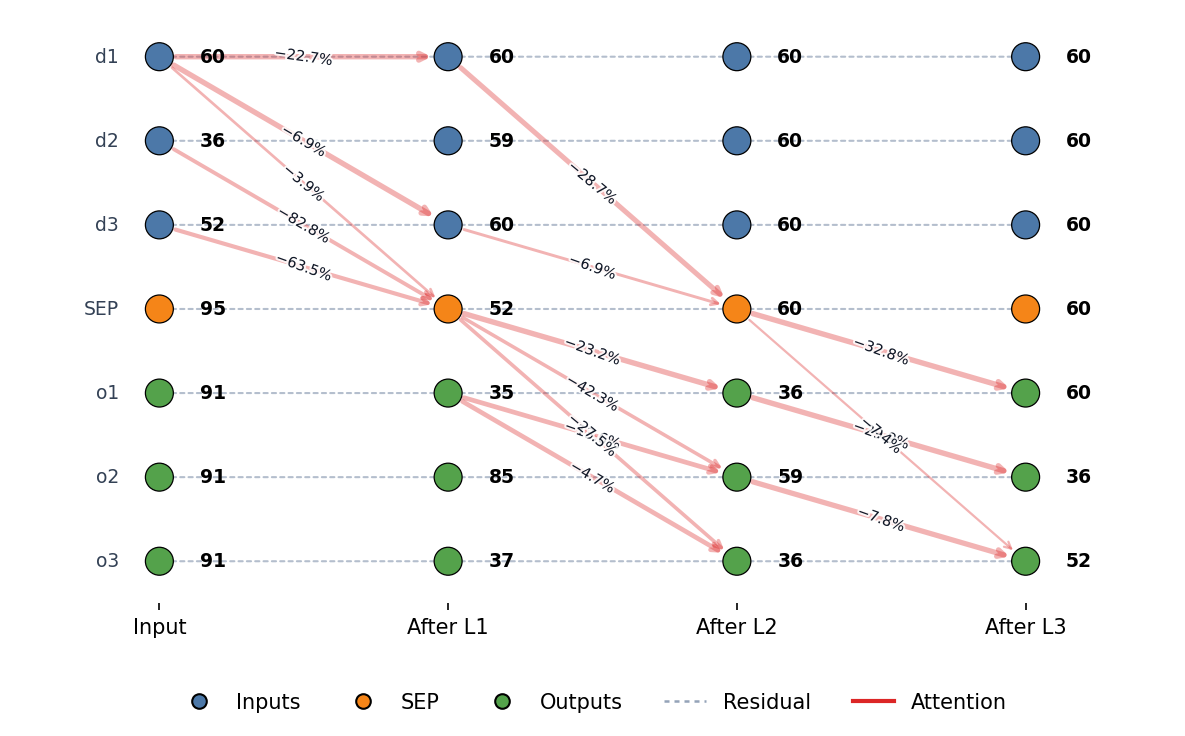

In [ ]:
# --- Visualize Attention Flow (Critical Edges Only) ---

# Pick a sample input to visualize
sample_idx = 0
example_input = val_inputs[sample_idx]

gen_attn_flow(
    model=model_3l,
    example_input=example_input,
    list_len=MODEL_3L_CFG.list_len,
    ablation_results=ablation_results,
    show_delta_labels=True,
    attention_threshold=0.04,
    figsize=(8, 5),
    dpi=150,
)

 Okay - seems that d2 may go d2 --> sep --> o2/o3 (not getting compressed)
 while d1 and d3 get compressed into sep in the 2nd layer, then decompressed in the 3rd layer.
 lets check the SEP attention vs accuracy next

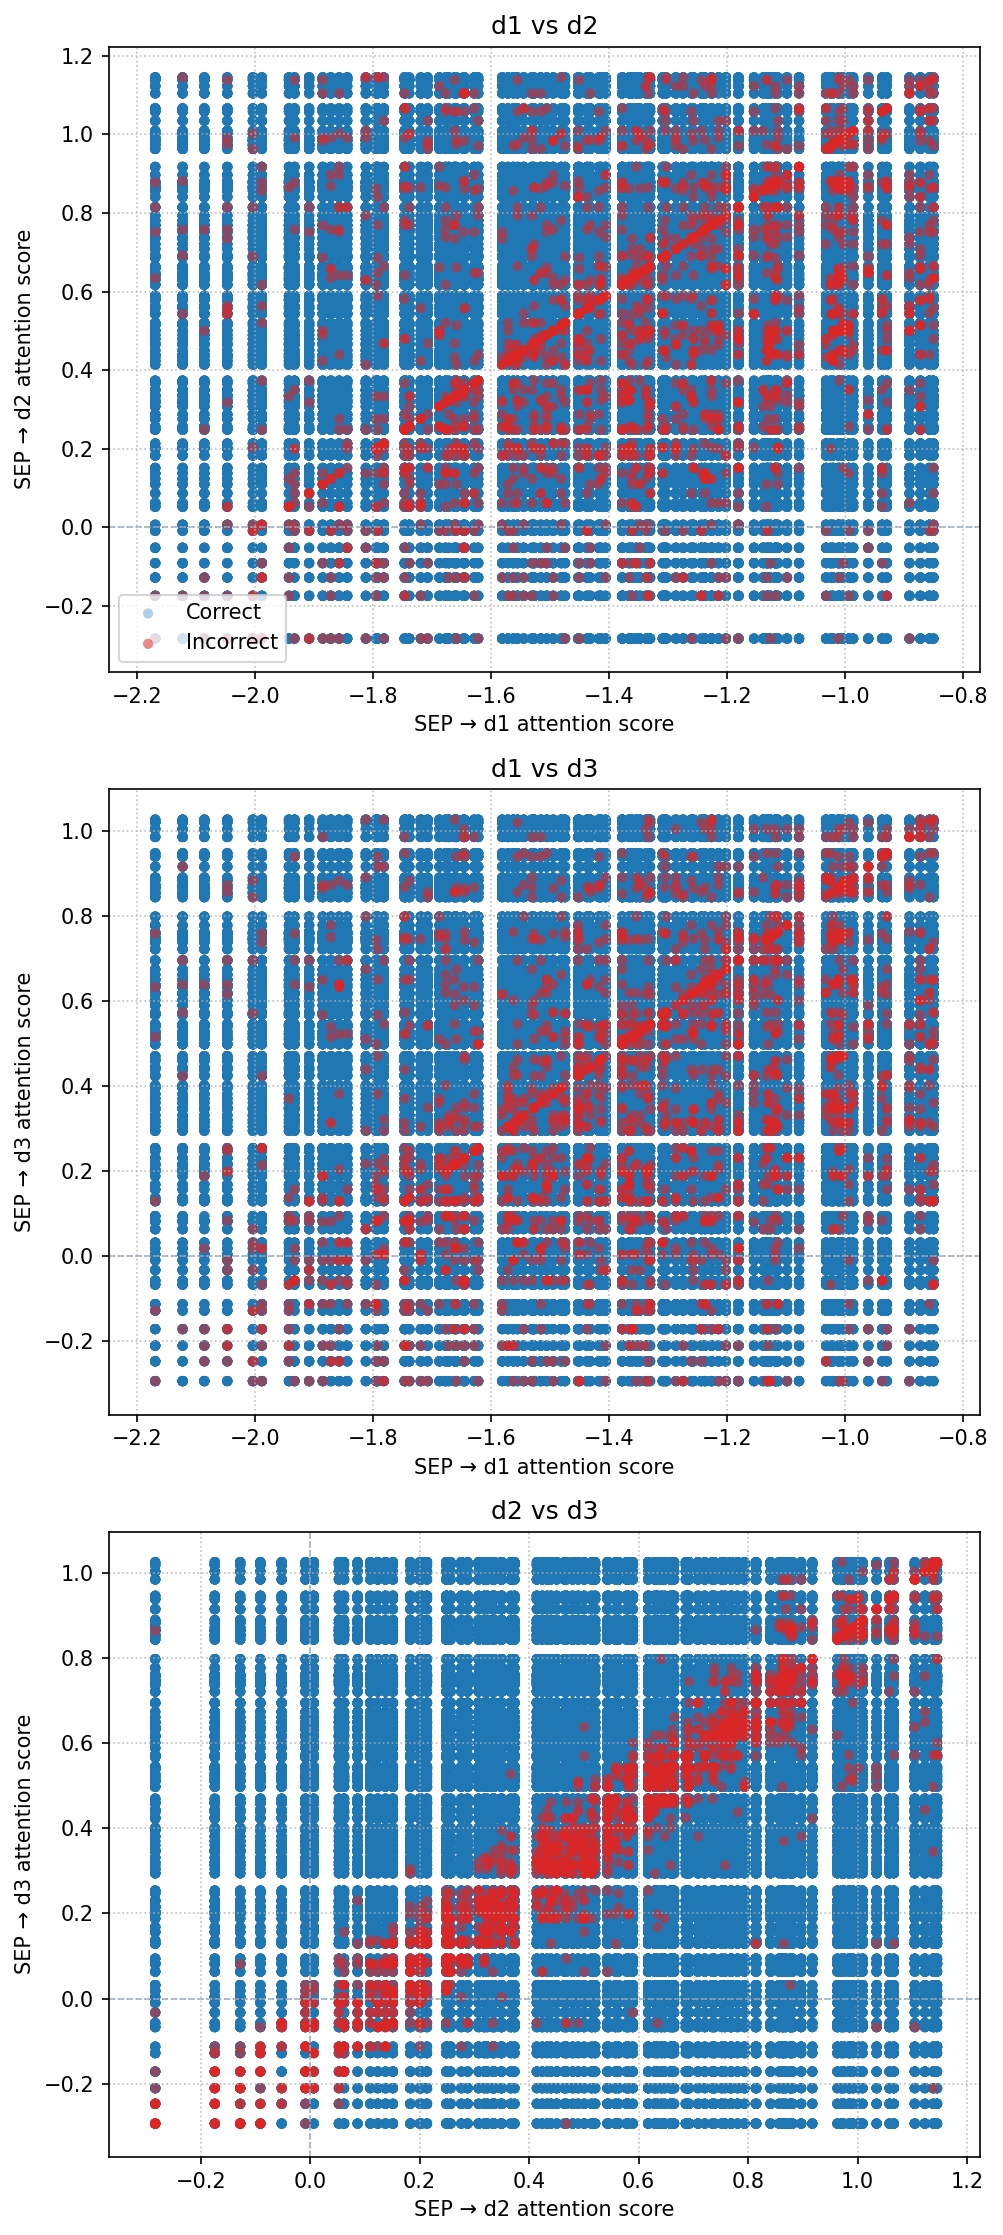

Total samples: 200000
Correct predictions: 197733
Accuracy: 0.989


<Figure size 640x480 with 0 Axes>

Total samples: 200000
Correct predictions: 197733
Accuracy: 0.989


In [ ]:
# --- SEP Attention vs Accuracy (Fig 3) ---

from model_scripts.interp_utils import plot_sep_attention_vs_accuracy

# Create 3 plots: d1 vs d2, d1 vs d3, d2 vs d3
position_pairs = [
    (0, 1, "d1 vs d2"),
    (0, 2, "d1 vs d3"),
    (1, 2, "d2 vs d3"),
]

plot_sep_attention_vs_accuracy(
    model=model_3l,
    val_inputs=val_inputs,
    val_targets=val_targets,
    list_len=MODEL_3L_CFG.list_len,
    layer=0,
    position_pairs=position_pairs,
    figsize=(6.8, 15),
    dpi=150,
    layout='column',
)

In [ ]:
# okay -- so it seems that d2 vs d3 has a very strong y=x line of errors (as in d1,d2 in the 2-layer model)
# but the ones with d1 aren't highly correlated, althought theres a bit of a y=x line
# 
# layer 1 is crazy --> not too much to get from that? just random patterns

In [ ]:
# check accuracy of o2 and o3 only
# (currently accuracy is on o1,o2,o3 - maybe o2,o3 accuracy is closer to 91% seen in 2 layer model)

with torch.no_grad():
    logits = model_3l(val_inputs)

# Get predictions and targets for all outputs
predictions_all = logits.argmax(dim=-1)[:, -3:]  # Last 3 output positions (o1, o2, o3)
targets_all = val_targets[:, -3:]  # Last 3 target positions

# Compute per-position accuracy
o1_correct = (predictions_all[:, 0] == targets_all[:, 0]).float().mean().item()
o2_correct = (predictions_all[:, 1] == targets_all[:, 1]).float().mean().item()
o3_correct = (predictions_all[:, 2] == targets_all[:, 2]).float().mean().item()

# Compute combined accuracies
both_o2_o3_correct = (predictions_all[:, 1:] == targets_all[:, 1:]).all(dim=-1)
accuracy_o2_o3 = both_o2_o3_correct.float().mean().item()

all_correct = (predictions_all == targets_all).all(dim=-1)
accuracy_all = all_correct.float().mean().item()

print("Per-position accuracy:")
print(f"  o1: {o1_correct:.4f} ({o1_correct*100:.2f}%)")
print(f"  o2: {o2_correct:.4f} ({o2_correct*100:.2f}%)")
print(f"  o3: {o3_correct:.4f} ({o3_correct*100:.2f}%)")
print(f"\nCombined accuracy:")
print(f"  o2 and o3 correct: {accuracy_o2_o3:.4f} ({accuracy_o2_o3*100:.2f}%)")
print(f"  All three correct: {accuracy_all:.4f} ({accuracy_all*100:.2f}%)")
print(f"\nTotal samples: {len(val_inputs)}")
print(f"Correct (o2 and o3): {both_o2_o3_correct.sum().item()}")
print(f"Correct (all three): {all_correct.sum().item()}")
print(f"Incorrect: {(~all_correct).sum().item()}") 

Per-position accuracy:
  o1: 0.9970 (99.70%)
  o2: 0.9985 (99.85%)
  o3: 0.9931 (99.31%)

Combined accuracy:
  o2 and o3 correct: 0.9917 (99.17%)
  All three correct: 0.9887 (98.87%)

Total samples: 200000
Correct (o2 and o3): 198331
Correct (all three): 197733
Incorrect: 2267


In [ ]:
# Analyze which positions are wrong in incorrect predictions

# Find all incorrect predictions (at least one position wrong)
incorrect_mask = ~all_correct

# For incorrect samples, check which positions are wrong
incorrect_predictions = predictions_all[incorrect_mask]
incorrect_targets = targets_all[incorrect_mask]

o1_wrong = (incorrect_predictions[:, 0] != incorrect_targets[:, 0]).sum().item()
o2_wrong = (incorrect_predictions[:, 1] != incorrect_targets[:, 1]).sum().item()
o3_wrong = (incorrect_predictions[:, 2] != incorrect_targets[:, 2]).sum().item()

n_incorrect = incorrect_mask.sum().item()

print(f"Analysis of {n_incorrect} incorrect predictions:")
print(f"  o1 wrong: {o1_wrong} ({o1_wrong/n_incorrect*100:.2f}%)")
print(f"  o2 wrong: {o2_wrong} ({o2_wrong/n_incorrect*100:.2f}%)")
print(f"  o3 wrong: {o3_wrong} ({o3_wrong/n_incorrect*100:.2f}%)")
print(f"\nNote: Percentages may sum to >100% if multiple positions are wrong in the same sample")

# Check how many have multiple positions wrong
only_one_wrong = ((incorrect_predictions != incorrect_targets).sum(dim=-1) == 1).sum().item()
two_wrong = ((incorrect_predictions != incorrect_targets).sum(dim=-1) == 2).sum().item()
all_three_wrong = ((incorrect_predictions != incorrect_targets).sum(dim=-1) == 3).sum().item()

print(f"\nError distribution:")
print(f"  Only one position wrong: {only_one_wrong} ({only_one_wrong/n_incorrect*100:.2f}%)")
print(f"  Two positions wrong: {two_wrong} ({two_wrong/n_incorrect*100:.2f}%)")
print(f"  All three wrong: {all_three_wrong} ({all_three_wrong/n_incorrect*100:.2f}%)")

Analysis of 2267 incorrect predictions:
  o1 wrong: 604 (26.64%)
  o2 wrong: 293 (12.92%)
  o3 wrong: 1377 (60.74%)

Note: Percentages may sum to >100% if multiple positions are wrong in the same sample

Error distribution:
  Only one position wrong: 2260 (99.69%)
  Two positions wrong: 7 (0.31%)
  All three wrong: 0 (0.00%)


 interesting! no cases where all 3 are wrong, and only 0.3% of errors are where 2 are wrong
 ==> 99.7% of errors are only 1 digit wrong

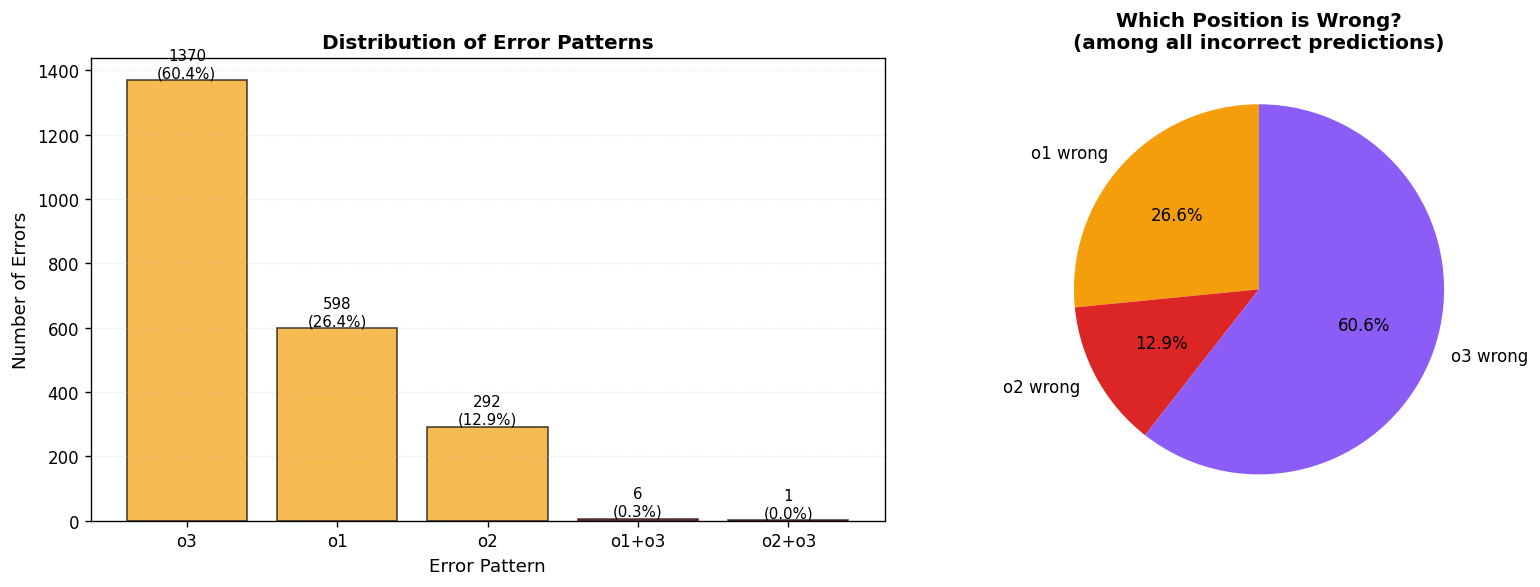


Error pattern breakdown:
  o3        : 1370 (60.43%)
  o1        :  598 (26.38%)
  o2        :  292 (12.88%)
  o1+o3     :    6 (0.26%)
  o2+o3     :    1 (0.04%)


In [ ]:
# Visualize error patterns

# Create error pattern breakdown
error_patterns = {}
for i in range(len(incorrect_predictions)):
    wrong_positions = []
    if incorrect_predictions[i, 0] != incorrect_targets[i, 0]:
        wrong_positions.append('o1')
    if incorrect_predictions[i, 1] != incorrect_targets[i, 1]:
        wrong_positions.append('o2')
    if incorrect_predictions[i, 2] != incorrect_targets[i, 2]:
        wrong_positions.append('o3')
    
    pattern = '+'.join(wrong_positions) if len(wrong_positions) > 1 else wrong_positions[0]
    error_patterns[pattern] = error_patterns.get(pattern, 0) + 1

# Sort by frequency
sorted_patterns = sorted(error_patterns.items(), key=lambda x: x[1], reverse=True)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Left plot: Error count by pattern
ax = axes[0]
patterns = [p[0] for p in sorted_patterns]
counts = [p[1] for p in sorted_patterns]
colors = ['#DC2626' if '+' in p else '#F59E0B' for p in patterns]

bars = ax.bar(patterns, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
ax.set_xlabel('Error Pattern', fontsize=11)
ax.set_ylabel('Number of Errors', fontsize=11)
ax.set_title('Distribution of Error Patterns', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle=':')

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/n_incorrect*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

# Right plot: Percentage breakdown with pie chart
ax = axes[1]
colors_pie = ['#F59E0B', '#DC2626', '#8B5CF6']
ax.pie([o1_wrong, o2_wrong, o3_wrong], 
       labels=['o1 wrong', 'o2 wrong', 'o3 wrong'],
       autopct='%1.1f%%',
       colors=colors_pie,
       startangle=90,
       textprops={'fontsize': 10})
ax.set_title('Which Position is Wrong?\n(among all incorrect predictions)', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nError pattern breakdown:")
for pattern, count in sorted_patterns:
    print(f"  {pattern:10s}: {count:4d} ({count/n_incorrect*100:.2f}%)")

 o2 has least errors --> which tracks earlier hyp from attn flow graph
 o3 has most errors, followed quite far behind by o1

Processing batches: 100%|██████████| 20/20 [00:01<00:00, 13.71it/s]


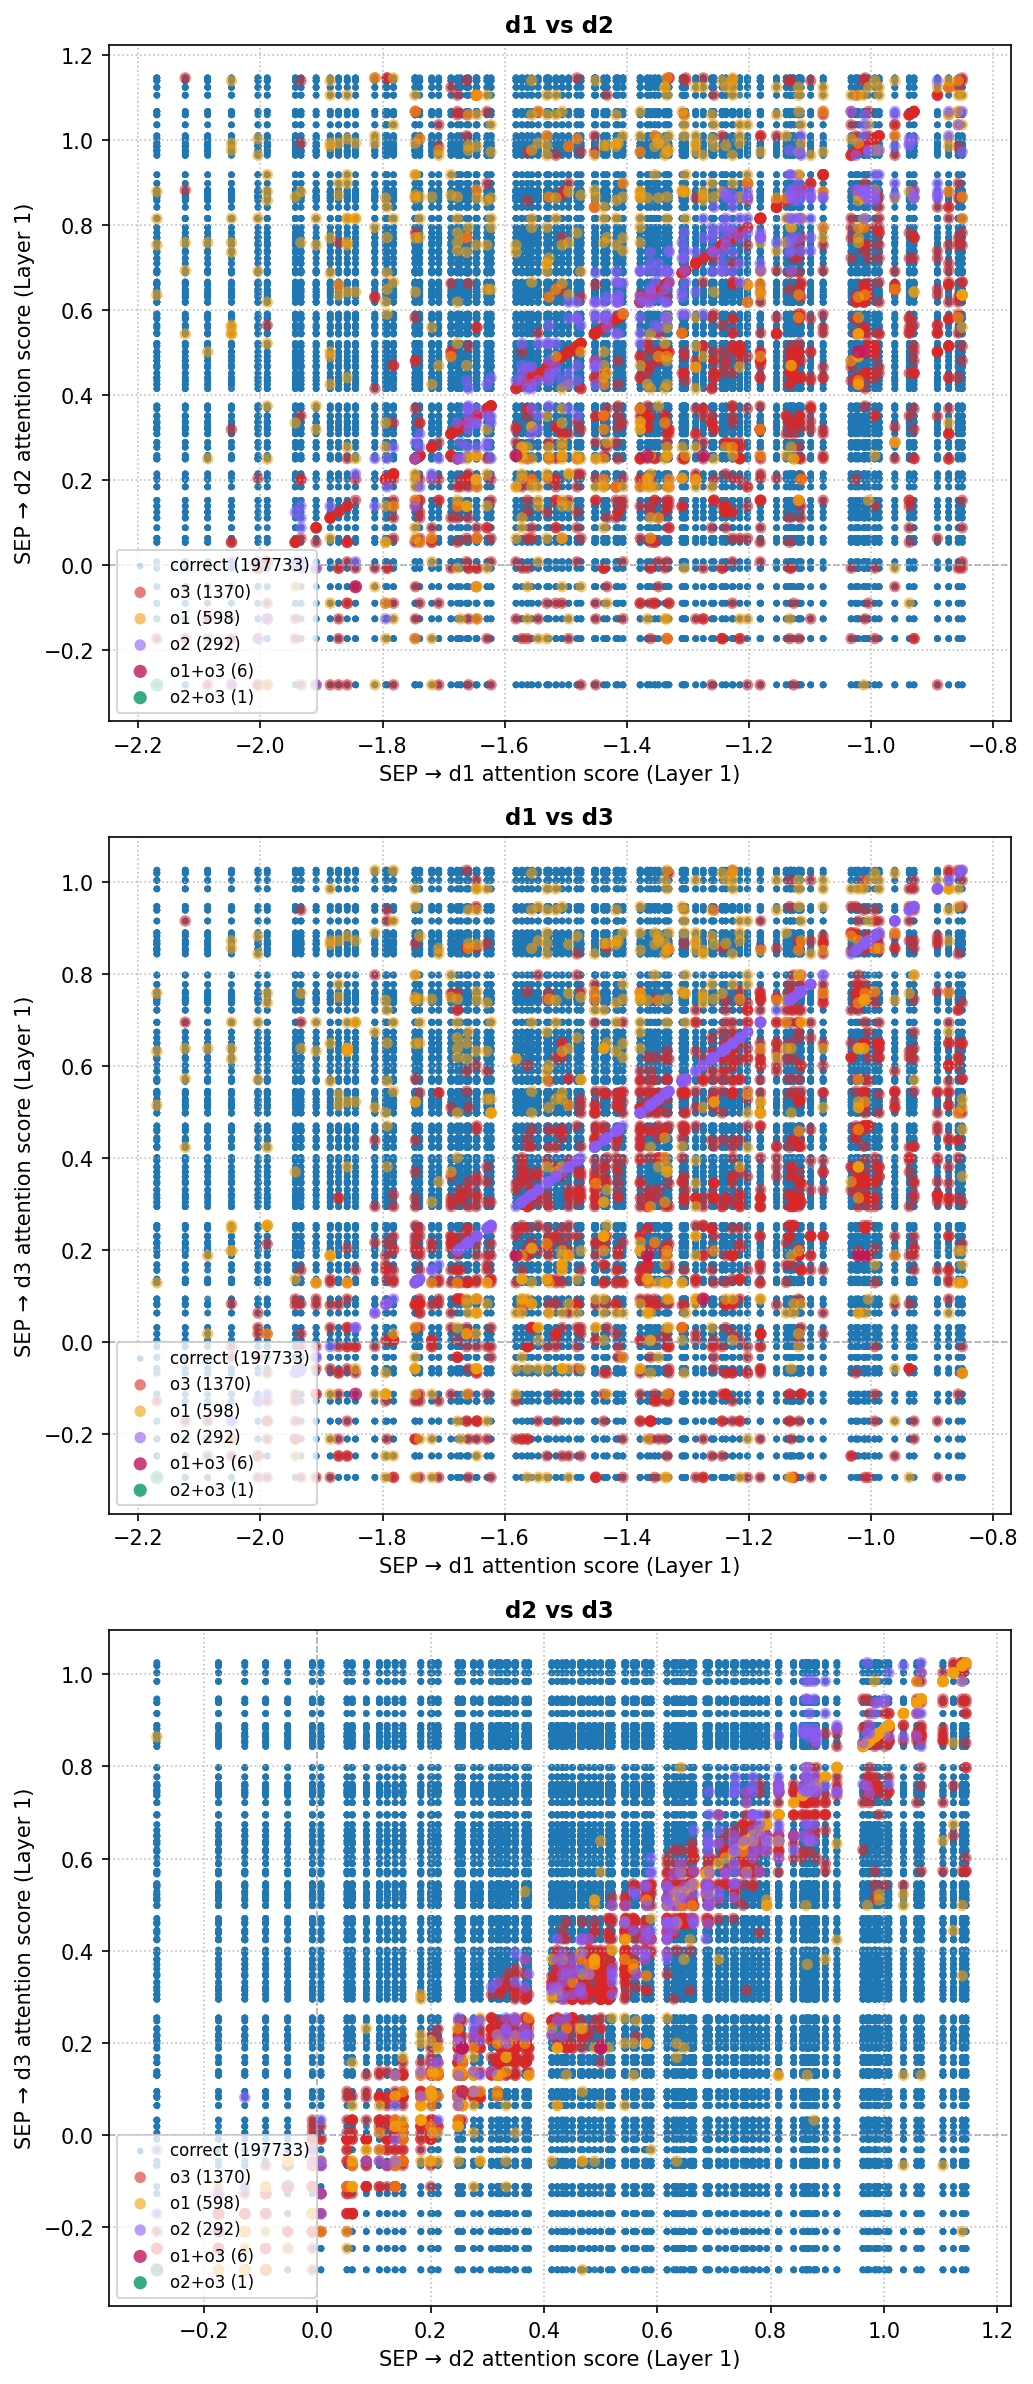

In [ ]:
# Layer 0 SEP attention colored by which position is wrong

# Process in batches to avoid OOM
batch_size = 10000
n_batches = (len(val_inputs) + batch_size - 1) // batch_size

all_predictions = []
all_scores_l0 = []

with torch.no_grad():
    for i in tqdm(range(n_batches), desc="Processing batches"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(val_inputs))
        batch_inputs = val_inputs[start_idx:end_idx]
        
        logits, cache = model_3l.run_with_cache(batch_inputs, return_type="logits")
        all_predictions.append(logits.argmax(dim=-1)[:, -3:].cpu())
        all_scores_l0.append(cache["attn_scores", 0][:, 0].cpu())

# Concatenate all batches
predictions = torch.cat(all_predictions, dim=0)
scores_l0 = torch.cat(all_scores_l0, dim=0)
targets = val_targets[:, -3:].cpu()

# Categorize each sample
error_category = []
for i in range(len(predictions)):
    if (predictions[i] == targets[i]).all():
        error_category.append('correct')
    else:
        wrong_pos = []
        if predictions[i, 0] != targets[i, 0]:
            wrong_pos.append('o1')
        if predictions[i, 1] != targets[i, 1]:
            wrong_pos.append('o2')
        if predictions[i, 2] != targets[i, 2]:
            wrong_pos.append('o3')
        error_category.append('+'.join(wrong_pos))

error_category = np.array(error_category)
sep_position = MODEL_3L_CFG.list_len

# Create plots
position_pairs = [
    (0, 1, "d1 vs d2"),
    (0, 2, "d1 vs d3"),
    (1, 2, "d2 vs d3"),
]

fig, axes = plt.subplots(3, 1, figsize=(7, 16), dpi=150)

# Color scheme
colors_map = {
    'correct': '#1f77b4',  # blue
    'o1': '#F59E0B',       # orange
    'o2': '#8B5CF6',       # purple
    'o3': '#DC2626',       # red
    'o1+o3': '#BE185D',    # pink
    'o2+o3': '#059669',    # green
}

for idx, (d1_pos, d2_pos, title) in enumerate(position_pairs):
    ax = axes[idx]
    
    attn_vals = scores_l0[:, sep_position, [d1_pos, d2_pos]].detach().cpu().numpy()
    x, y = attn_vals[:, 0], attn_vals[:, 1]
    
    # Plot in order: correct first (background), then errors by frequency
    plot_order = ['correct', 'o3', 'o1', 'o2', 'o1+o3', 'o2+o3']
    sizes = {'correct': 10, 'o1': 30, 'o2': 30, 'o3': 30, 'o1+o3': 40, 'o2+o3': 40}
    alphas = {'correct': 0.25, 'o1': 0.6, 'o2': 0.6, 'o3': 0.6, 'o1+o3': 0.8, 'o2+o3': 0.8}
    
    for category in plot_order:
        mask = error_category == category
        if mask.any():
            ax.scatter(x[mask], y[mask], 
                      s=sizes.get(category, 30), 
                      c=colors_map.get(category, '#999999'), 
                      alpha=alphas.get(category, 0.5),
                      edgecolors='none',
                      label=f'{category} ({mask.sum()})')
    
    # Reference lines at 0
    ax.axvline(0, color="#94A3B8", lw=0.8, ls="--", alpha=0.8)
    ax.axhline(0, color="#94A3B8", lw=0.8, ls="--", alpha=0.8)
    
    # Axes limits
    x_lo, x_hi = np.percentile(x, [1, 99])
    y_lo, y_hi = np.percentile(y, [1, 99])
    pad_x = 0.06 * max(1e-6, x_hi - x_lo)
    pad_y = 0.06 * max(1e-6, y_hi - y_lo)
    
    ax.set_xlabel(f"SEP → d{d1_pos+1} attention score (Layer 1)", fontsize=10)
    ax.set_ylabel(f"SEP → d{d2_pos+1} attention score (Layer 1)", fontsize=10)
    ax.set_xlim(x_lo - pad_x, x_hi + pad_x)
    ax.set_ylim(y_lo - pad_y, y_hi + pad_y)
    ax.grid(True, linestyle=":", alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(frameon=True, loc="best", fontsize=8)

plt.tight_layout()
plt.show()